<a href="https://colab.research.google.com/github/Bala-Durga-Krishnaveni/Dakshina_Assignment/blob/main/Dakshina_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision torchaudio
!pip install pandas numpy matplotlib seaborn scikit-learn tqdm wandb

**IMPORT LIBRARIES**

In [10]:
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import wandb

**DEVICE CONFIGURATION**

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


**LOAD DATASET**
Dataset format:
romanized\tnative
Example:
ghar\tघर
namaste\tनमस्ते

In [12]:
train_df = pd.read_csv(
    'hi.translit.sampled.train.tsv',
    sep='\t',
    header=None
)
val_df = pd.read_csv(
    'hi.translit.sampled.dev.tsv',
    sep='\t',
    header=None
)
train_df.columns = ['native', 'romanized', 'count']
val_df.columns = ['native', 'romanized', 'count']

train_df = train_df[['romanized', 'native']]
val_df=val_df[['romanized', 'native']]

print(train_df.head())

  romanized   native
0        an       अं
1  ankganit  अंकगणित
2     uncle     अंकल
3     ankur    अंकुर
4   ankuran   अंकुरण


**PREPROCESSING**
Special Tokens
PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
UNK_TOKEN = '<UNK>'

In [13]:
PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
UNK_TOKEN = '<UNK>'

**BUILD VOCABULARY**

In [14]:
class Vocabulary:
    def __init__(self):
        self.char2idx = {
            PAD_TOKEN: 0,
            SOS_TOKEN: 1,
            EOS_TOKEN: 2,
            UNK_TOKEN: 3
        }

        self.idx2char = {
            0: PAD_TOKEN,
            1: SOS_TOKEN,
            2: EOS_TOKEN,
            3: UNK_TOKEN
        }

        self.n_chars = 4

    def add_word(self, word):
        for ch in word:
            self.add_char(ch)

    def add_char(self, ch):
        if ch not in self.char2idx:
            self.char2idx[ch] = self.n_chars
            self.idx2char[self.n_chars] = ch
            self.n_chars += 1

    def word_to_indices(self, word):
        indices = [self.char2idx.get(ch, self.char2idx[UNK_TOKEN]) for ch in word]
        indices.append(self.char2idx[EOS_TOKEN])
        return indices

    def indices_to_word(self, indices):
        chars = []
        for idx in indices:
            if idx == self.char2idx[EOS_TOKEN]:
                break
            chars.append(self.idx2char[idx])
        return ''.join(chars)

**CREATE INPUT AND OUTPUT VOCABULARIES**

In [15]:
input_vocab = Vocabulary()
output_vocab = Vocabulary()

for _, row in train_df.iterrows():
    input_vocab.add_word(str(row['romanized']))
    output_vocab.add_word(str(row['native']))

print(input_vocab.n_chars)
print(output_vocab.n_chars)

30
67


In [16]:
max_input_len = max(
    len(str(word))
    for word in train_df['romanized']
)

max_output_len = max(
    len(str(word))
    for word in train_df['native']
)

T = max(
    max_input_len,
    max_output_len
)
print("Sequence Length (T):", T)

Sequence Length (T): 20


**DATASET CLASS**

In [17]:
class TransliterationDataset(Dataset):

    def __init__(self, dataframe, input_vocab, output_vocab):
        self.dataframe = dataframe
        self.input_vocab = input_vocab
        self.output_vocab = output_vocab

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        src_word = str(row['romanized'])
        tgt_word = str(row['native'])

        src_indices = self.input_vocab.word_to_indices(src_word)

        tgt_indices = [self.output_vocab.char2idx[SOS_TOKEN]]
        tgt_indices += self.output_vocab.word_to_indices(tgt_word)

        return torch.tensor(src_indices), torch.tensor(tgt_indices)

**PADDING FUNCTION**

In [18]:
from torch.nn.utils.rnn import pad_sequence


def collate_fn(batch):
    src_batch = [item[0] for item in batch]
    tgt_batch = [item[1] for item in batch]

    src_batch = pad_sequence(src_batch, padding_value=0, batch_first=True)
    tgt_batch = pad_sequence(tgt_batch, padding_value=0, batch_first=True)

    return src_batch, tgt_batch

**DATA LOADERS**

In [19]:
train_dataset = TransliterationDataset(train_df, input_vocab, output_vocab)
val_dataset = TransliterationDataset(val_df, input_vocab, output_vocab)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

**ENCODER**

In [20]:
class Encoder(nn.Module):

    def __init__(
        self,
        input_dim,
        emb_dim,
        hidden_dim,
        num_layers,
        dropout,
        cell_type='LSTM'
    ):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)

        if cell_type == 'RNN':
            self.rnn = nn.RNN(
                emb_dim,
                hidden_dim,
                num_layers=num_layers,
                dropout=dropout,
                batch_first=True
            )

        elif cell_type == 'GRU':
            self.rnn = nn.GRU(
                emb_dim,
                hidden_dim,
                num_layers=num_layers,
                dropout=dropout,
                batch_first=True
            )

        else:
            self.rnn = nn.LSTM(
                emb_dim,
                hidden_dim,
                num_layers=num_layers,
                dropout=dropout,
                batch_first=True
            )

        self.dropout = nn.Dropout(dropout)
        self.cell_type = cell_type

    def forward(self, src):

        embedded = self.dropout(self.embedding(src))

        outputs, hidden = self.rnn(embedded)

        return outputs, hidden

**DECODER WITH ATTENTION**

In [21]:
class Decoder(nn.Module):

    def __init__(
        self,
        output_dim,
        emb_dim,
        hidden_dim,
        num_layers,
        dropout,
        attention,
        cell_type='LSTM'
    ):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.cell_type = cell_type

        self.embedding = nn.Embedding(output_dim, emb_dim)

        input_size = emb_dim + hidden_dim

        if cell_type == 'RNN':
            self.rnn = nn.RNN(
                input_size,
                hidden_dim,
                num_layers=num_layers,
                dropout=dropout,
                batch_first=True
            )

        elif cell_type == 'GRU':
            self.rnn = nn.GRU(
                input_size,
                hidden_dim,
                num_layers=num_layers,
                dropout=dropout,
                batch_first=True
            )

        else:
            self.rnn = nn.LSTM(
                input_size,
                hidden_dim,
                num_layers=num_layers,
                dropout=dropout,
                batch_first=True
            )

        self.fc_out = nn.Linear(hidden_dim * 2 + emb_dim, output_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):

        input = input.unsqueeze(1)

        embedded = self.dropout(self.embedding(input))

        if self.cell_type == 'LSTM':
            hidden_state = hidden[0][-1]
        else:
            hidden_state = hidden[-1]

        attention = self.attention(hidden_state, encoder_outputs)

        attention = attention.unsqueeze(1)

        weighted = torch.bmm(attention, encoder_outputs)

        rnn_input = torch.cat((embedded, weighted), dim=2)

        output, hidden = self.rnn(rnn_input, hidden)

        prediction = self.fc_out(
            torch.cat(
                (
                    output.squeeze(1),
                    weighted.squeeze(1),
                    embedded.squeeze(1)
                ),
                dim=1
            )
        )

        return prediction, hidden, attention

**SEQ2SEQ MODEL**

In [22]:
class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):

        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        encoder_outputs, hidden = self.encoder(src)

        input = tgt[:, 0]

        for t in range(1, tgt_len):

            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)

            outputs[:, t] = output

            top1 = output.argmax(1)

            teacher_force = random.random() < teacher_forcing_ratio

            input = tgt[:, t] if teacher_force else top1

        return outputs

**HYPERPARAMETERS**

In [23]:
INPUT_DIM = input_vocab.n_chars
OUTPUT_DIM = output_vocab.n_chars

EMB_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3

CELL_TYPE = 'RNN'

**ATTENTION LAYER**

In [24]:
class Attention(nn.Module):

    def __init__(self, hidden_dim):
        super().__init__()

        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):

        src_len = encoder_outputs.shape[1]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)

        energy = torch.tanh(
            self.attn(torch.cat((hidden, encoder_outputs), dim=2))
        )

        attention = self.v(energy).squeeze(2)

        return torch.softmax(attention, dim=1)

**INITIALISE MODEL**

In [25]:
attention = Attention(HIDDEN_DIM)

encoder = Encoder(
    INPUT_DIM,
    EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT,
    CELL_TYPE
)


decoder = Decoder(
    OUTPUT_DIM,
    EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT,
    attention,
    CELL_TYPE
)

model = Seq2Seq(encoder, decoder, device).to(device)

**LOSS AND OPTIMIZER**

In [26]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=0.001)

**WANDB INITIALIZATION**

In [46]:
wandb.init(
    project='dakshina-transliteration',
    config={
        'embedding_dim': EMB_DIM,
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT,
        'cell_type': CELL_TYPE,
        'batch_size': 64,
        'learning_rate': 0.001
    }
)

**TRAINING FUNCTION**

In [28]:
def train(model, loader, optimizer, criterion, clip=1):

    model.train()

    epoch_loss = 0

    for src, tgt in tqdm(loader):

        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()

        output = model(src, tgt)

        output_dim = output.shape[-1]

        output = output[:, 1:].reshape(-1, output_dim)
        tgt = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

**EVALUATION FUNCTION**

In [29]:
def evaluate(model, loader, criterion):

    model.eval()

    epoch_loss = 0

    with torch.no_grad():

        for src, tgt in loader:

            src = src.to(device)
            tgt = tgt.to(device)

            output = model(src, tgt, 0)

            output_dim = output.shape[-1]

            output = output[:, 1:].reshape(-1, output_dim)
            tgt = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt)

            epoch_loss += loss.item()

    return epoch_loss / len(loader)

**ACCURACY FUNCTION**

In [30]:
def transliterate(model, word):

    model.eval()

    indices = input_vocab.word_to_indices(word)

    src_tensor = torch.tensor(indices).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    input_token = torch.tensor([output_vocab.char2idx[SOS_TOKEN]]).to(device)

    outputs = []

    for _ in range(30):

        with torch.no_grad():
            output, hidden, attention = model.decoder(
                input_token,
                hidden,
                encoder_outputs
            )

        pred_token = output.argmax(1).item()

        if pred_token == output_vocab.char2idx[EOS_TOKEN]:
            break

        outputs.append(output_vocab.idx2char[pred_token])

        input_token = torch.tensor([pred_token]).to(device)

    return ''.join(outputs)

**COMPUTE WORD ACCURACY**

In [31]:
def compute_accuracy(model, dataframe):

    correct = 0
    total = 0

    for _, row in dataframe.iterrows():

        src = str(row['romanized'])
        tgt = str(row['native'])

        pred = transliterate(model, src)

        if pred == tgt:
            correct += 1

        total += 1

    return correct / total

**TRAINING LOOP**

In [32]:
N_EPOCHS = 5

best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):

    train_loss = train(model, train_loader, optimizer, criterion)

    valid_loss = evaluate(model, val_loader, criterion)
    train_acc = compute_accuracy(
        model,
        train_df[:1000]
    )

    valid_acc = compute_accuracy(
        model,
        val_df[:500]
    )

    wandb.log({
        'epoch':epoch,
        'train_loss': train_loss,
        'valid_loss': valid_loss,
        'train_accuracy': train_acc,
        'valid_accuracy': valid_acc
    })

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model.pt')

    print(f'Epoch: {epoch+1}')
    print(f'Train Loss: {train_loss:.4f}')
    print(f'Val Loss: {valid_loss:.4f}')
    print(f'Training Accuracy: {train_acc:.4f}')
    print(f'Validation Accuracy: {valid_acc:.4f}')

100%|██████████| 691/691 [00:30<00:00, 22.67it/s]


Epoch: 1
Train Loss: 1.4423
Val Loss: 1.2519
Training Accuracy: 0.1540
Validation Accuracy: 0.1060


100%|██████████| 691/691 [00:29<00:00, 23.25it/s]


Epoch: 2
Train Loss: 0.8955
Val Loss: 1.1190
Training Accuracy: 0.2440
Validation Accuracy: 0.1940


100%|██████████| 691/691 [00:29<00:00, 23.04it/s]


Epoch: 3
Train Loss: 0.7858
Val Loss: 1.0797
Training Accuracy: 0.3120
Validation Accuracy: 0.2160


100%|██████████| 691/691 [00:31<00:00, 22.28it/s]


Epoch: 4
Train Loss: 0.7172
Val Loss: 1.0608
Training Accuracy: 0.2660
Validation Accuracy: 0.2060


100%|██████████| 691/691 [00:30<00:00, 22.52it/s]


Epoch: 5
Train Loss: 0.6820
Val Loss: 1.0070
Training Accuracy: 0.3230
Validation Accuracy: 0.2240


**LOAD BEST MODEL**

In [34]:
model.load_state_dict(torch.load('best_model.pt'))

<All keys matched successfully>

**TEST PREDICTIONS**

In [35]:
words = [
    'ghar',
    'namaste',
    'bharat',
    'krishna'
]

for word in words:
    print(word, '->', transliterate(model, word))

ghar -> रार
namaste -> नमस्ते
bharat -> तरत
krishna -> कृष्ण


**ATTENTION VISUALIZATION**

In [36]:
def visualize_attention(model, word):

    model.eval()

    indices = input_vocab.word_to_indices(word)

    src_tensor = torch.tensor(indices).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    input_token = torch.tensor([output_vocab.char2idx[SOS_TOKEN]]).to(device)

    attentions = []
    outputs = []

    for _ in range(30):

        with torch.no_grad():
            output, hidden, attention = model.decoder(
                input_token,
                hidden,
                encoder_outputs
            )

        pred_token = output.argmax(1).item()

        if pred_token == output_vocab.char2idx[EOS_TOKEN]:
            break

        outputs.append(output_vocab.idx2char[pred_token])

        attentions.append(attention.cpu().numpy().squeeze())

        input_token = torch.tensor([pred_token]).to(device)
    attentions = np.vstack(attentions)
    plt.figure(figsize=(10, 8))

    sns.heatmap(
        attentions,
        xticklabels=list(word) + ['<EOS>'],
        yticklabels=outputs,
        cmap='Blues'
    )

    plt.xlabel('Input Characters')
    plt.ylabel('Output Characters')
    plt.show()

**RUN ATTENTION VISUALIZATION**

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA})

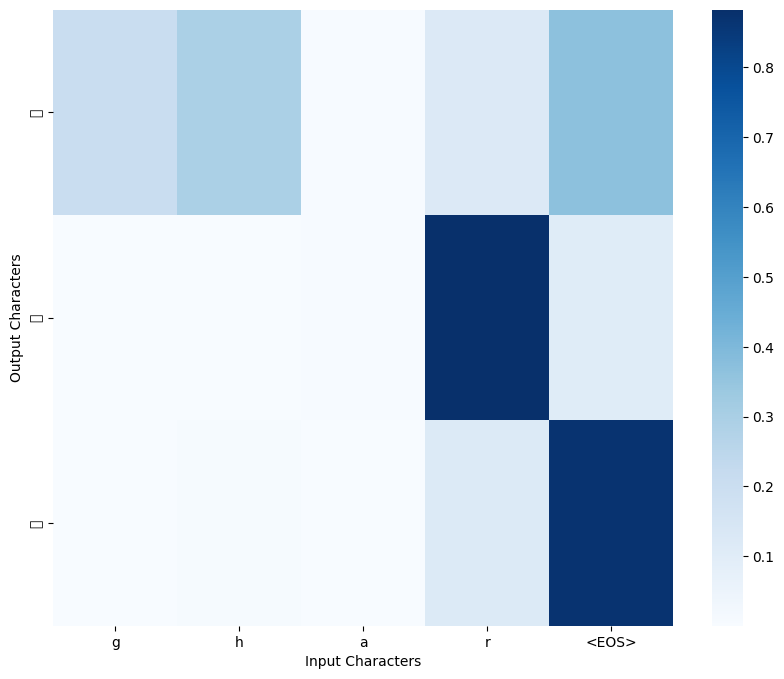

In [37]:
visualize_attention(model, 'ghar')

**FINAL ACCURACY**

In [39]:
accuracy = compute_accuracy(model, val_df)
accuracy1 = compute_accuracy(model, train_df)

print('Validation Accuracy:', accuracy)
print('Training Accuracy:', accuracy1)

Validation Accuracy: 0.29004130335016065
Training Accuracy: 0.335060175549724


**SAVE COMPLETE MODEL**

In [40]:
torch.save({
    'model_state_dict': model.state_dict(),
    'input_vocab': input_vocab,
    'output_vocab': output_vocab
}, 'transliteration_model.pth')

**HYPERPARAMETER USING WANDB**

In [41]:
sweep_config = {
    'method': 'random',
    'metric': {
        'name': 'valid_accuracy',
        'goal': 'maximize'
    },
    "parameters": {
        "layer_type": {
            "values": ["GRU", "LSTM", "SimpleRNN"]
        },
        "dropout": {
            "values": [0.0, 0.2]
        },
        "units": {
            "values": [64,128,256]
        },
        "embedding_dim": {
            "values": [16,32,64]
        },
        "optimiser": {
            "values": ["nadam"]
        },
        "epochs": {
            "values": [20]
        },
        "batch_size": {
            "values": [128]
        },
        "num_layers": {
            "values": [1, 2,3]
        }
}
}

**CREATE SWEEP**

In [42]:
def train_model():

    wandb.init(project='dakshina-transliteration')

    config = wandb.config
    embedding_dim = config.embedding_dim
    hidden_dim = config.units
    num_layers = config.num_layers
    dropout = config.dropout
    cell_type = config.layer_type
    batch_size = config.batch_size
    epochs = config.epochs
    optimizer_name = config.optimiser

In [43]:
import time
start_time=time.time()
total_training_time=time.time()-start_time

In [47]:
wandb.run.summary['valid_accuracy']=valid_acc
wandb.run.summary['train_accuracy']=train_acc
wandb.run.summary['runtime']=total_training_time

In [48]:
sweep_id = wandb.sweep(
    sweep_config,
    project='dakshina-transliteration'
)

Create sweep with ID: 6z7rw2yr
Sweep URL: https://wandb.ai/kellakrishnaveni123-/dakshina-transliteration/sweeps/6z7rw2yr


In [49]:
wandb.log({

    'epoch': epoch + 1,

    'train_loss': train_loss,

    'valid_loss': valid_loss,

    'train_accuracy': train_acc,

    'valid_accuracy': valid_acc
})

In [50]:
import wandb

try:
    wandb.finish()
except:
    pass

epoch,▁
train_accuracy,▁
train_loss,▁
valid_accuracy,▁
valid_loss,▁
epoch,5
runtime,8e-05
train_accuracy,0.323
train_loss,0.68201
valid_accuracy,0.224
valid_loss,1.007


**RUN SWEEP**

In [51]:
wandb.agent(
    sweep_id,
    function=train_model,
    count=20
)

wandb: Agent Starting Run: 5kmb6cod with config:
wandb: 	batch_size: 128
wandb: 	dropout: 0
wandb: 	embedding_dim: 16
wandb: 	epochs: 20
wandb: 	layer_type: GRU
wandb: 	num_layers: 3
wandb: 	optimiser: nadam
wandb: 	units: 256
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb: Agent Starting Run: m6qe5u4f with config:
wandb: 	batch_size: 128
wandb: 	dropout: 0
wandb: 	embedding_dim: 32
wandb: 	epochs: 20
wandb: 	layer_type: SimpleRNN
wandb: 	num_layers: 1
wandb: 	optimiser: nadam
wandb: 	units: 256
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb: Agent Starting Run: iprrohr9 with config:
wandb: 	batch_size: 128
wandb: 	dropout: 0.2
wandb: 	embedding_dim: 16
wandb: 	epochs: 20
wandb: 	layer_type: GRU
wandb: 	num_layers: 3
wandb: 	optimiser: nadam
wandb: 	units: 64
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb: Agent Starting Run: nwb26ges with config:
wandb: 	batch_size: 128
wandb: 	dropout: 0
wandb: 	embedding_dim: 32
wandb: 	epochs: 20
wandb: 	layer_type: LSTM
wandb: 	num_layers: 1
wandb: 	optimiser: nadam
wandb: 	units: 256
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb: Agent Starting Run: 16u4515i with config:
wandb: 	batch_size: 128
wandb: 	dropout: 0
wandb: 	embedding_dim: 64
wandb: 	epochs: 20
wandb: 	layer_type: SimpleRNN
wandb: 	num_layers: 2
wandb: 	optimiser: nadam
wandb: 	units: 64
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


...

wandb: Agent Starting Run: q4nl3tpr with config:
wandb: 	batch_size: 128
wandb: 	dropout: 0.2
wandb: 	embedding_dim: 32
wandb: 	epochs: 20
wandb: 	layer_type: LSTM
wandb: 	num_layers: 1
wandb: 	optimiser: nadam
wandb: 	units: 128
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb: Agent Starting Run: ti1novtd with config:
wandb: 	batch_size: 128
wandb: 	dropout: 0
wandb: 	embedding_dim: 16
wandb: 	epochs: 20
wandb: 	layer_type: SimpleRNN
wandb: 	num_layers: 1
wandb: 	optimiser: nadam
wandb: 	units: 128
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb: Agent Starting Run: wm8p3b7c with config:
wandb: 	batch_size: 128
wandb: 	dropout: 0
wandb: 	embedding_dim: 16
wandb: 	epochs: 20
wandb: 	layer_type: GRU
wandb: 	num_layers: 2
wandb: 	optimiser: nadam
wandb: 	units: 64
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb: Agent Starting Run: f0ywoav6 with config:
wandb: 	batch_size: 128
wandb: 	dropout: 0.2
wandb: 	embedding_dim: 32
wandb: 	epochs: 20
wandb: 	layer_type: GRU
wandb: 	num_layers: 3
wandb: 	optimiser: nadam
wandb: 	units: 64
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb: Agent Starting Run: fdrduqj0 with config:
wandb: 	batch_size: 128
wandb: 	dropout: 0.2
wandb: 	embedding_dim: 16
wandb: 	epochs: 20
wandb: 	layer_type: GRU
wandb: 	num_layers: 1
wandb: 	optimiser: nadam
wandb: 	units: 128
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
